In [23]:
import cv2
import numpy as np
import os
from skimage.feature import graycomatrix, graycoprops
from skimage.feature import local_binary_pattern
from sklearn.cluster import KMeans
import pandas as pd

# ===== SETTINGS =====
DATASET_PATH = "roi_output"

GLCM_CSV = "glcm_features.csv"
KMEANS_CSV = "kmeans_features.csv"

glcm_list = []
kmeans_list = []

labels_glcm = []
labels_kmeans = []

for class_name in os.listdir(DATASET_PATH):

    class_path = os.path.join(DATASET_PATH, class_name)
    if not os.path.isdir(class_path):
        continue

    for img_name in os.listdir(class_path):

        img_path = os.path.join(class_path, img_name)

        img = cv2.imread(img_path, 0)
        if img is None:
            continue

        img = cv2.resize(img, (128, 128))

        # =========================
        # 🔹 GLCM + LBP FEATURES
        # =========================

        # ----- GLCM -----
        glcm = graycomatrix(img, distances=[1], angles=[0, np.pi/4],
                            levels=256, symmetric=True, normed=True)

        contrast = graycoprops(glcm, 'contrast').flatten()
        energy = graycoprops(glcm, 'energy').flatten()
        homogeneity = graycoprops(glcm, 'homogeneity').flatten()
        correlation = graycoprops(glcm, 'correlation').flatten()

        glcm_features = np.hstack([contrast, energy, homogeneity, correlation])


        # ----- LBP -----
        radius = 1
        n_points = 8 * radius

        lbp = local_binary_pattern(img, n_points, radius, method='uniform')

        # LBP histogram
        lbp_hist, _ = np.histogram(
            lbp.ravel(),
            bins=np.arange(0, n_points + 3),
            range=(0, n_points + 2)
        )

        # normalize
        lbp_hist = lbp_hist.astype("float")
        lbp_hist /= (lbp_hist.sum() + 1e-6)

        # =========================
        # 🔹 HISTOGRAM (ADD TO GLCM)
        # =========================
        mean = np.mean(img)
        std = np.std(img)

        hist, _ = np.histogram(img.flatten(), bins=256, range=[0,256])
        prob = hist / np.sum(hist)
        entropy = -np.sum(prob * np.log2(prob + 1e-10))

        hist_features = [mean, std, entropy]

        # =========================
        # 🔹 FINAL COMBINED FEATURES
        # =========================
        glcm_lbp_features = np.hstack([
            glcm_features,
            lbp_hist,
            hist_features   #  added
        ])

        glcm_list.append(glcm_lbp_features)
        labels_glcm.append(class_name)


        # =========================
        #  K-MEANS FEATURES (HISTOGRAM BASED)
        # =========================

        # Compute histogram
        hist = cv2.calcHist([img], [0], None, [256], [0, 256]).flatten()

        # Create weighted samples (intensity repeated by frequency)
        samples = []
        for i in range(256):
            samples += [i] * int(hist[i])

        samples = np.array(samples).reshape(-1, 1)

        # Apply KMeans
        kmeans = KMeans(n_clusters=2, random_state=0).fit(samples)

        # Sort centers
        centers = np.sort(kmeans.cluster_centers_.flatten())
        c1, c2 = centers

        # Distance between centroids
        distance = abs(c2 - c1)

        # Get labels and counts
        labels_k = kmeans.labels_
        counts = np.bincount(labels_k)

        # Fix p1 → ensure it corresponds to smaller centroid (c1)
        if kmeans.cluster_centers_[0] < kmeans.cluster_centers_[1]:
            p1 = counts[0] / len(labels_k)
        else:
            p1 = counts[1] / len(labels_k)

        # Feature vector
        kmeans_features = [c1, c2, distance, p1]

        # Store
        kmeans_list.append(kmeans_features)
        labels_kmeans.append(class_name)



# ===== SAVE GLCM CSV =====
df_glcm = pd.DataFrame(glcm_list)
df_glcm['label'] = labels_glcm
df_glcm.to_csv(GLCM_CSV, index=False)


# ===== SAVE KMEANS CSV =====
df_kmeans = pd.DataFrame(kmeans_list)
df_kmeans['label'] = labels_kmeans
df_kmeans.to_csv(KMEANS_CSV, index=False)


print("2 CSV files saved ")

2 CSV files saved 


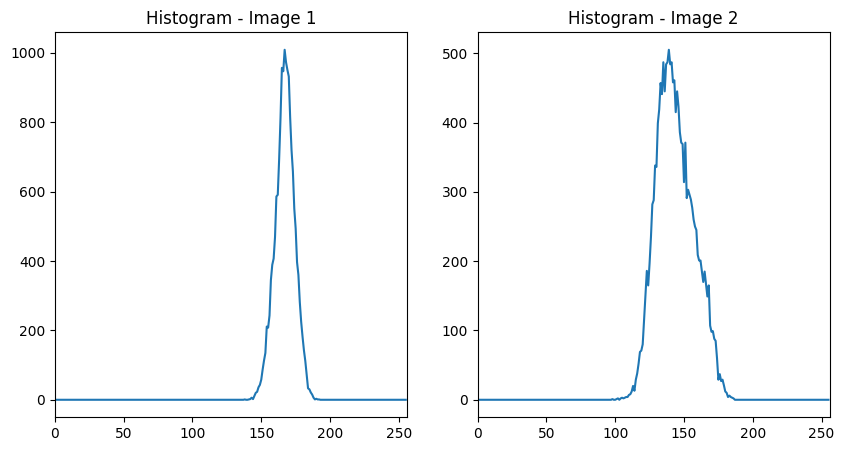

In [25]:
import cv2
import matplotlib.pyplot as plt

# Load images (grayscale)
img1 = cv2.imread('53.jpg', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('145.jpg', cv2.IMREAD_GRAYSCALE)

# Compute histograms
hist1 = cv2.calcHist([img1], [0], None, [256], [0, 256])
hist2 = cv2.calcHist([img2], [0], None, [256], [0, 256])

# Plot histograms
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Histogram - Image 1")
plt.plot(hist1)
plt.xlim([0,256])

plt.subplot(1,2,2)
plt.title("Histogram - Image 2")
plt.plot(hist2)
plt.xlim([0,256])

plt.show()

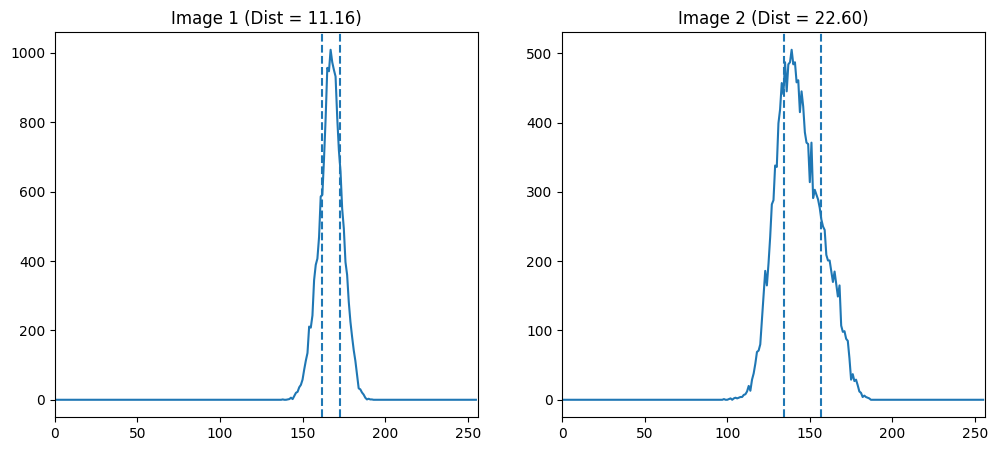

Image 1 centroids: [161.67265 172.8324 ]  Distance: 11.159744
Image 2 centroids: [134.34428 156.94617]  Distance: 22.601883


In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load images (grayscale)
img1 = cv2.imread('53.jpg', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('145.jpg', cv2.IMREAD_GRAYSCALE)

# Compute histograms
hist1 = cv2.calcHist([img1], [0], None, [256], [0, 256]).flatten()
hist2 = cv2.calcHist([img2], [0], None, [256], [0, 256]).flatten()

# K-means function
def apply_kmeans(hist):
    samples = []
    for i in range(256):
        samples += [i] * int(hist[i])
    
    samples = np.array(samples).reshape(-1,1).astype(np.float32)

    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    _, labels, centers = cv2.kmeans(samples, 2, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

    centers = np.sort(centers.flatten())
    return centers

# Apply K-means
centers1 = apply_kmeans(hist1)
centers2 = apply_kmeans(hist2)

# Distance within each histogram
dist1 = abs(centers1[1] - centers1[0])
dist2 = abs(centers2[1] - centers2[0])

# ------------------ PLOTTING ------------------

plt.figure(figsize=(12,5))

# Image 1
plt.subplot(1,2,1)
plt.title(f"Image 1 (Dist = {dist1:.2f})")
plt.plot(hist1)
for c in centers1:
    plt.axvline(x=c, linestyle='--')
plt.xlim([0,256])

# Image 2
plt.subplot(1,2,2)
plt.title(f"Image 2 (Dist = {dist2:.2f})")
plt.plot(hist2)
for c in centers2:
    plt.axvline(x=c, linestyle='--')
plt.xlim([0,256])

plt.show()

# Print results
print("Image 1 centroids:", centers1, " Distance:", dist1)
print("Image 2 centroids:", centers2, " Distance:", dist2)

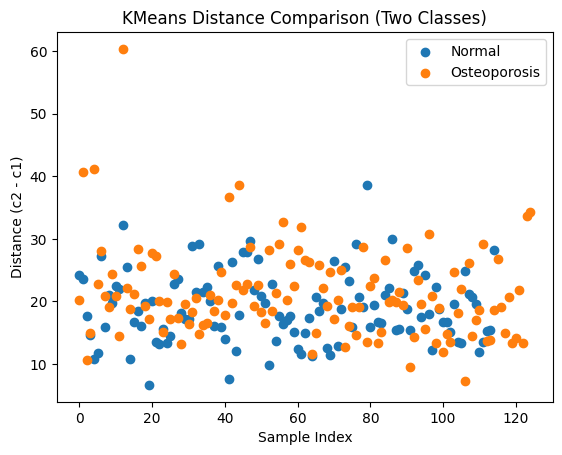

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# ===== LOAD CSV =====
df = pd.read_csv("kmeans_features.csv")

# ===== CHECK LABELS =====
labels = df['label'].unique()

if len(labels) != 2:
    raise ValueError("This plot expects exactly 2 labels")

label1, label2 = labels[0], labels[1]

# ===== SPLIT DATA =====
df1 = df[df['label'] == label1]
df2 = df[df['label'] == label2]

# ===== PLOT =====
plt.figure()

# Plot distances (column index 2)
plt.scatter(range(len(df1)), df1.iloc[:, 2], label=label1)
plt.scatter(range(len(df2)), df2.iloc[:, 2], label=label2)

plt.xlabel("Sample Index")
plt.ylabel("Distance (c2 - c1)")
plt.title("KMeans Distance Comparison (Two Classes)")
plt.legend()

plt.show()

In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Models
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier


def run_experiment(file_path, dataset_name):
    print(f"\n===== {dataset_name} DATASET =====")

    # Load data
    df = pd.read_csv(file_path)

    X = df.drop(columns=['label'])
    y = df['label']

    # Normalize
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Models
    models = {
        "SVM": SVC(kernel='rbf', C=1, gamma="scale"),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "RandomForest": RandomForestClassifier(n_estimators=50, n_jobs=-1),
        "LogisticRegression": LogisticRegression(max_iter=500),
        "DecisionTree": DecisionTreeClassifier(max_depth=5),
        "ExtraTrees": ExtraTreesClassifier(n_estimators=100)
    }

    results = []

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

        print(f"{name}: Acc={acc:.4f}, Prec={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}")

        results.append((name, acc, precision, recall, f1))


# ===== RUN FOR BOTH DATASETS =====
run_experiment("glcm_features.csv", "GLCM")
run_experiment("kmeans_features.csv", "KMeans")


===== GLCM DATASET =====
SVM: Acc=0.8125, Prec=0.8165, Recall=0.8125, F1=0.8113
KNN: Acc=0.7292, Prec=0.7300, Recall=0.7292, F1=0.7293
RandomForest: Acc=0.7708, Prec=0.7709, Recall=0.7708, F1=0.7705
LogisticRegression: Acc=0.7500, Prec=0.7500, Recall=0.7500, F1=0.7500
DecisionTree: Acc=0.6667, Prec=0.6691, Recall=0.6667, F1=0.6631
ExtraTrees: Acc=0.7708, Prec=0.7709, Recall=0.7708, F1=0.7705

===== KMeans DATASET =====
SVM: Acc=0.5833, Prec=0.5886, Recall=0.5833, F1=0.5819
KNN: Acc=0.5833, Prec=0.5854, Recall=0.5833, F1=0.5833
RandomForest: Acc=0.7083, Prec=0.7108, Recall=0.7083, F1=0.7083
LogisticRegression: Acc=0.5417, Prec=0.5461, Recall=0.5417, F1=0.5401
DecisionTree: Acc=0.5417, Prec=0.5393, Recall=0.5417, F1=0.5318
ExtraTrees: Acc=0.6042, Prec=0.6037, Recall=0.6042, F1=0.6016


In [15]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# ===== SETTINGS =====
DATASET_PATH = "roi_output"
BATCH_SIZE = 4
IMG_SIZE = 128
EPOCHS = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===== TRANSFORM =====
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(DATASET_PATH, transform=transform)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_data, test_data = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)

# ===== MODELS =====
model_names = {
    "ResNet18": models.resnet18(pretrained=True),
    "ResNet50": models.resnet50(pretrained=True),
    "VGG16": models.vgg16(pretrained=True),
    "MobileNet": models.mobilenet_v2(pretrained=True),
    "EfficientNet": models.efficientnet_b0(pretrained=True)
}

results = []

for name, model in model_names.items():

    print(f"\nRunning {name}")

    # Modify last layer
    if "resnet" in name.lower():
        model.fc = nn.Linear(model.fc.in_features, 3)
    elif "vgg" in name.lower():
        model.classifier[6] = nn.Linear(4096, 3)
    elif "mobilenet" in name.lower():
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 3)
    elif "efficientnet" in name.lower():
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 3)

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # ===== TRAIN =====
    model.train()
    for epoch in range(EPOCHS):
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # ===== TEST =====
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, pred = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (pred == labels).sum().item()

    acc = correct / total
    print(f"{name} Accuracy: {acc:.4f}")

    results.append((name, acc))


print("\n===== DL COMPARISON =====")
for name, acc in results:
    print(f"{name}: {acc:.4f}")

c:\Users\sunda\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\sunda\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
c:\Users\sunda\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.


Running ResNet18
ResNet18 Accuracy: 0.5000

Running ResNet50
ResNet50 Accuracy: 0.7708

Running VGG16
VGG16 Accuracy: 0.4375

Running MobileNet
MobileNet Accuracy: 0.7292

Running EfficientNet
EfficientNet Accuracy: 0.7292

===== DL COMPARISON =====
ResNet18: 0.5000
ResNet50: 0.7708
VGG16: 0.4375
MobileNet: 0.7292
EfficientNet: 0.7292


In [29]:
import torch
if torch.cuda.is_available():
    print("yes")
    device = torch.device("cuda")
else:
    device = torch.device("cpu")


yes


In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ===== SETTINGS =====
DATASET_PATH = "roi_output"
BATCH_SIZE = 32
EPOCHS = 50
IMG_SIZE = 128

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===== TRANSFORMS =====
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# ===== DATASET =====
dataset = datasets.ImageFolder(DATASET_PATH, transform=transform)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ===== MODEL =====
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Linear(64 * 16 * 16, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 3)   # 3 classes
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = CNN().to(device)

# ===== LOSS & OPTIMIZER =====
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ===== TRAINING =====
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {total_loss:.4f}")

# ===== EVALUATION =====
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total

print("\n===== CNN RESULT =====")
print(f"Accuracy: {accuracy:.4f}")

Epoch [1/50], Loss: 5.0689
Epoch [2/50], Loss: 4.2554
Epoch [3/50], Loss: 3.7763
Epoch [4/50], Loss: 3.8735
Epoch [5/50], Loss: 3.7999
Epoch [6/50], Loss: 3.7641
Epoch [7/50], Loss: 3.5408
Epoch [8/50], Loss: 3.6209
Epoch [9/50], Loss: 3.5361
Epoch [10/50], Loss: 3.5109
Epoch [11/50], Loss: 3.5933
Epoch [12/50], Loss: 3.4196
Epoch [13/50], Loss: 3.3674
Epoch [14/50], Loss: 3.4596
Epoch [15/50], Loss: 3.5855
Epoch [16/50], Loss: 3.4276
Epoch [17/50], Loss: 3.4301
Epoch [18/50], Loss: 3.4850
Epoch [19/50], Loss: 3.4328
Epoch [20/50], Loss: 3.2478
Epoch [21/50], Loss: 3.2958
Epoch [22/50], Loss: 3.1801
Epoch [23/50], Loss: 3.1809
Epoch [24/50], Loss: 3.0826
Epoch [25/50], Loss: 3.0405
Epoch [26/50], Loss: 2.9515
Epoch [27/50], Loss: 3.1639
Epoch [28/50], Loss: 2.8576
Epoch [29/50], Loss: 2.8620
Epoch [30/50], Loss: 2.9633
Epoch [31/50], Loss: 2.9680
Epoch [32/50], Loss: 2.7445
Epoch [33/50], Loss: 2.6734
Epoch [34/50], Loss: 2.6575
Epoch [35/50], Loss: 2.6921
Epoch [36/50], Loss: 2.5619
E

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F

# ===== SETTINGS =====
DATASET_PATH = "roi_output"
BATCH_SIZE = 32
EPOCHS = 2
IMG_SIZE = 128

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===== TRANSFORMS =====
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# ===== DATASET =====
dataset = datasets.ImageFolder(DATASET_PATH, transform=transform)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ===== FEATURE EXTRACTION =====
def get_features(x):
    x_pad = F.pad(x, (1,1,1,1), mode='reflect')

    n1 = x_pad[:, :, :-2, :-2]
    n2 = x_pad[:, :, :-2, 1:-1]
    n3 = x_pad[:, :, :-2, 2:]
    n4 = x_pad[:, :, 1:-1, :-2]
    n5 = x_pad[:, :, 1:-1, 2:]
    n6 = x_pad[:, :, 2:, :-2]
    n7 = x_pad[:, :, 2:, 1:-1]
    n8 = x_pad[:, :, 2:, 2:]

    features = torch.cat([
        (x - n1), (x - n2), (x - n3), (x - n4),
        (x - n5), (x - n6), (x - n7), (x - n8)
    ], dim=1)  # (B, 8, H, W)

    return features

# ===== PURE ANN MODEL =====
class PureANN(nn.Module):
    def __init__(self):
        super().__init__()

        input_size = 8 * IMG_SIZE * IMG_SIZE  

        self.fc = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, 128),
            nn.ReLU(),

            nn.Linear(128, 3)  # 3 classes
        )

    def forward(self, x):
        x = get_features(x)             # (B, 8, H, W)
        x = x.view(x.size(0), -1)       # flatten
        x = self.fc(x)
        return x

# ===== MODEL =====
model = PureANN().to(device)

# ===== LOSS & OPTIMIZER =====
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ===== TRAINING =====
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {total_loss:.4f}")

# ===== EVALUATION =====
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total

print("\n===== PURE ANN RESULT =====")
print(f"Accuracy: {accuracy:.4f}")

Epoch [1/2], Loss: 6.3021
Epoch [2/2], Loss: 1.7768

===== PURE ANN RESULT =====
Accuracy: 0.6458
